# QC comparing different assembly 

- Verkko + PoreC
- Verkko + Trio
- Hifasm + Trio
- Hifiasm + PoreC
- Verkko + PoFo (Parent of Origin Detection)


In [1]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(gt))
source("../scripts/00_R_presets.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘purrr’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
Scanning ttf files in ../../doc/figures/helvetica ...

Extracting .afm files from .ttf files...

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Condensed Regular.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Roman.ttf
 : Helvetica already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/helvetica_condensed.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica-Bold Oblique.ttf
 : Helvetica-BoldOblique already registered in fonts database. Skipping.

/mnt/storage3b/projects/no_ngsd/a

## Comparison Hifiasm Verkko

In [2]:
source("../scripts/13_process_assembly_qc.R")
dt_trio <- read_tsv("../../assembly/qc/qc_trio.tsv", show_col_types = FALSE) %>%
    process_qc_table(selection = metrics_phased) %>%
    mutate(assembler = case_when(
        asm_method == "phased_verkko" ~ "Verkko",
        asm_method == "phased_hifiasm" ~ "Hifiasm")) %>%
    mutate(phasing = ifelse( str_detect(asm_name, "trio"), "Trio", "PoreC" )) %>%
    mutate(haplotype = ifelse(haplotype == "assembly", "both", haplotype)) %>%
    rowwise() %>%
    mutate(sample = str_split_1(asm_name, "_")[1]) %>%
    ungroup() %>%
    select(sample, phasing, assembler, haplotype, metric, value)
dt_trio

sample,phasing,assembler,haplotype,metric,value
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
T2T00,Trio,Verkko,haplotype1,length,3.050015e+09
T2T00,Trio,Verkko,haplotype1,ref_covered,9.383000e-01
T2T00,Trio,Verkko,haplotype1,asm_covered,9.720000e-01
T2T00,Trio,Verkko,haplotype2,length,2.943505e+09
T2T00,Trio,Verkko,haplotype2,ref_covered,8.996000e-01
T2T00,Trio,Verkko,haplotype2,asm_covered,9.662000e-01
T2T04,Trio,Verkko,haplotype1,length,3.066373e+09
T2T04,Trio,Verkko,haplotype1,ref_covered,9.349000e-01
T2T04,Trio,Verkko,haplotype1,asm_covered,9.689000e-01


In [3]:
dt_trio_wide <- dt_trio %>%
  group_by(sample, phasing, assembler, haplotype, metric) %>%
  filter(haplotype != "both") %>%
  summarise(value = sum(value, na.rm = TRUE), .groups = 'drop') %>%
  pivot_wider(names_from = metric, values_from = value) %>%
  write_tsv(file = "../../doc/tables/qc_trio_table.tsv")
  

dt_trio_wide %>%
  knitr::kable()



|sample |phasing |assembler |haplotype  |       MMC|       MSC| asm_covered| genome_completeness|     length| n_contigs| n_contigs_over_10mb| n_t2t_contig| n_t2t_scaffold| ref_covered| total_gaps| total_n_count|
|:------|:-------|:---------|:----------|---------:|---------:|-----------:|-------------------:|----------:|---------:|-------------------:|------------:|--------------:|-----------:|----------:|-------------:|
|T2T00  |PoreC   |Hifiasm   |haplotype1 | 0.2322888| 0.0223988|      0.9715|           0.9848829| 3039093532|        87|                  44|            0|              2|      0.9354|         47|       2249069|
|T2T00  |PoreC   |Hifiasm   |haplotype2 | 0.1859673| 0.0625450|      0.9644|           0.9427709| 2941756249|        85|                  44|            0|              2|      0.8986|         50|       4357883|
|T2T00  |PoreC   |Verkko    |haplotype1 | 0.1757493| 0.0537682|      0.9698|           0.9492774| 2926888795|        44|                  23|         

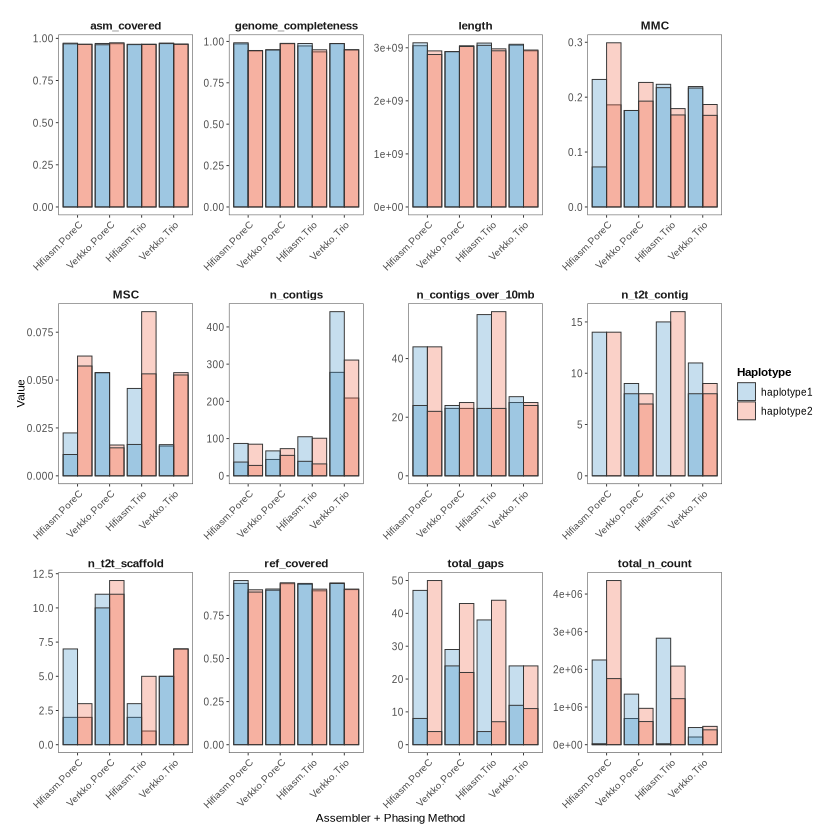

In [4]:

plot_qc_method_comparison <- dt_trio %>%
  filter(haplotype != "both") %>%
  ggplot(aes(x = interaction(assembler, phasing), y = value, fill = interaction(haplotype))) +
    geom_bar(stat = "identity", position = "dodge", alpha = 0.3, colour = "grey20") +
    facet_wrap(~metric, scales = "free") +
    labs(
         x = "Assembler + Phasing Method",
         y = "Value",
         fill = "Haplotype") +
    scale_fill_manual(values = col_haplotype ) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

ggsave("../../doc/figures/trioeval_qc_comparison.png", 
       plot_qc_method_comparison, width = 7, height = 6, dpi = 300)

plot_qc_method_comparison

## Phasing QC: Trio vs PoreC vs PoFo 

In [27]:
# Load trioeval data
dt_trioeval_summary <- read_tsv("../../analysis_other/trioeval/trioeval_summary.tsv", show_col_types = F)
dt_trioeval_contigs <- read_tsv("../../analysis_other/trioeval/trioeval_per_contig.tsv", show_col_types = F)

dt_trioeval_summary
head(dt_trioeval_contigs)

sample,method,haplotype,switch_error_rate,switch_errors,switch_denominator,hamming_error_rate,hamming_errors,hamming_denominator,total_error_rate,total_pat_kmer,total_mat_kmer
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T2T00,verkko_porec,haplotype1,0.015902,51072,3211761,0.012766,41002,3211804,0.251435,2404244,807560
T2T00,verkko_porec,haplotype2,0.027114,52197,1925115,0.019626,37784,1925186,0.441352,849686,1075501
T2T04,verkko_porec,haplotype1,0.012103,38256,3160915,0.008117,25658,3160982,0.347484,2062591,1098391
T2T04,verkko_porec,haplotype2,0.024765,41970,1694731,0.016537,28026,1694786,0.338947,1120343,574443
T2T00,verkko_trio,haplotype1,0.027138,50951,1877501,0.017673,33186,1877769,0.017693,33223,1844551
T2T00,verkko_trio,haplotype2,0.016035,52584,3279260,0.013905,45600,3279467,0.013921,3233816,45652
T2T04,verkko_trio,haplotype1,0.022346,37491,1677715,0.015109,25356,1678153,0.015235,25567,1652587
T2T04,verkko_trio,haplotype2,0.013166,43425,3298154,0.008642,28504,3298459,0.008662,3269894,28571
T2T00,hifiasm_trio,haplotype1,0.025485,70417,2763123,0.047731,131891,2763228,0.360616,996465,1766763


sample,method,haplotype,contig,length,pat_kmer,mat_kmer,pat_pat,pat_mat,mat_pat,⋯,predicted_origin,asm_switch_errors,asm_switch_denominator,asm_switch_error_rate,asm_hamming_errors,asm_hamming_denominator,asm_hamming_error_rate,asm_total_pat_kmer,asm_total_mat_kmer,asm_total_error_rate
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T2T00,verkko_porec,haplotype1,haplotype1-0000001,245398328,131368,3368,129101,2266,2267,⋯,paternal,51072,3211761,0.015902,41002,3211804,0.012766,2404244,807560,0.251435
T2T00,verkko_porec,haplotype1,haplotype1-0000002,78991454,38030,1689,37370,659,659,⋯,paternal,51072,3211761,0.015902,41002,3211804,0.012766,2404244,807560,0.251435
T2T00,verkko_porec,haplotype1,haplotype1-0000003,39963702,20604,1688,20309,294,294,⋯,paternal,51072,3211761,0.015902,41002,3211804,0.012766,2404244,807560,0.251435
T2T00,verkko_porec,haplotype1,haplotype1-0000004,136566791,75033,1703,73843,1189,1189,⋯,paternal,51072,3211761,0.015902,41002,3211804,0.012766,2404244,807560,0.251435
T2T00,verkko_porec,haplotype1,haplotype1-0000005,200680242,90710,2781,89169,1540,1540,⋯,paternal,51072,3211761,0.015902,41002,3211804,0.012766,2404244,807560,0.251435
T2T00,verkko_porec,haplotype1,haplotype1-0000006,83836360,1554,34129,463,1091,1091,⋯,maternal,51072,3211761,0.015902,41002,3211804,0.012766,2404244,807560,0.251435


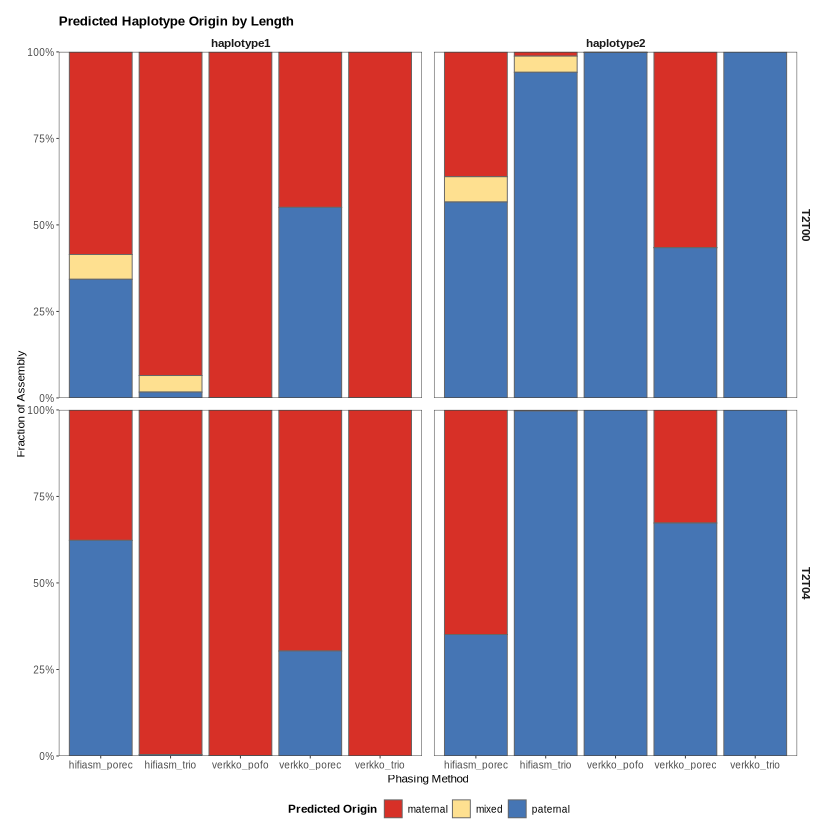

In [28]:
# Plot 4: Predicted origin distribution
dt_origin_summary <- dt_trioeval_contigs %>%
    group_by(sample, method, haplotype, predicted_origin) %>%
    summarise(
        n_contigs = n(),
        total_length = sum(length),
        .groups = "drop"
    ) %>%
    group_by(sample, method, haplotype) %>%
    mutate(
        fraction_by_count = n_contigs / sum(n_contigs),
        fraction_by_length = total_length / sum(total_length)
    )

p_origin <- ggplot(dt_origin_summary, 
    aes(x = method, y = fraction_by_length, fill = predicted_origin)) +
    geom_col(position = "stack", col = "grey40") +
    facet_grid(sample ~ haplotype) +
    scale_y_continuous(labels = scales::percent, expand = c(0, 0)) +
    scale_fill_manual(
        values = c("paternal" = "#4575b4", "maternal" = "#d73027", "mixed" = "#fee090"),
        name = "Predicted Origin"
    ) +
    labs(
        title = "Predicted Haplotype Origin by Length",
        x = "Phasing Method",
        y = "Fraction of Assembly"
    ) +
    theme(legend.position = "bottom")

p_origin

ggsave(filename = "../../doc/figures/trioeval_origin.pdf", plot = p_origin, width = 10, height = 6, units = "in")
ggsave(filename = "../../doc/figures/trioeval_origin.png", width = 10, height = 6, units = "in")

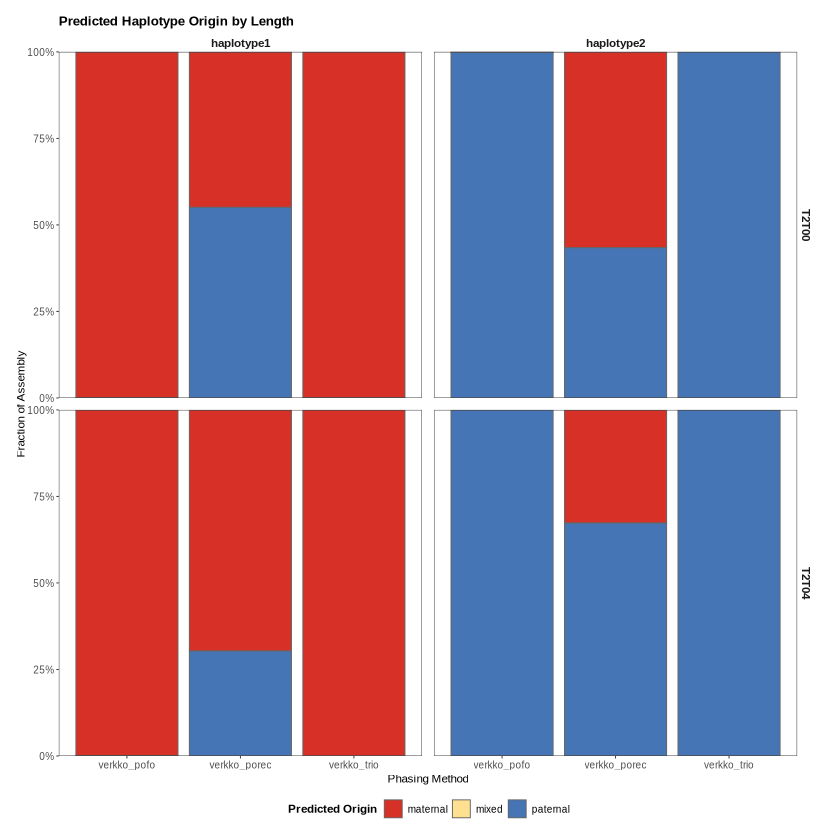

In [30]:
# Plot 4: Predicted origin distribution Verkko Only

p_origin_verkko <- ggplot(dt_origin_summary %>% filter(str_detect(method, "verkko")), 
    aes(x = method, y = fraction_by_length, fill = predicted_origin)) +
    geom_col(position = "stack", col = "grey40") +
    facet_grid(sample ~ haplotype) +
    scale_y_continuous(labels = scales::percent, expand = c(0, 0)) +
    scale_fill_manual(
        values = c("paternal" = "#4575b4", "maternal" = "#d73027", "mixed" = "#fee090"),
        name = "Predicted Origin"
    ) +
    labs(
        title = "Predicted Haplotype Origin by Length",
        x = "Phasing Method",
        y = "Fraction of Assembly"
    ) +
    theme(legend.position = "bottom")

p_origin_verkko

ggsave(filename = "../../doc/figures/trioeval_origin_verkko.pdf", plot = p_origin_verkko, width = 10, height = 6, units = "in")
ggsave(filename = "../../doc/figures/trioeval_origin_verkko.png", plot = p_origin_verkko, width = 10, height = 6, units = "in")

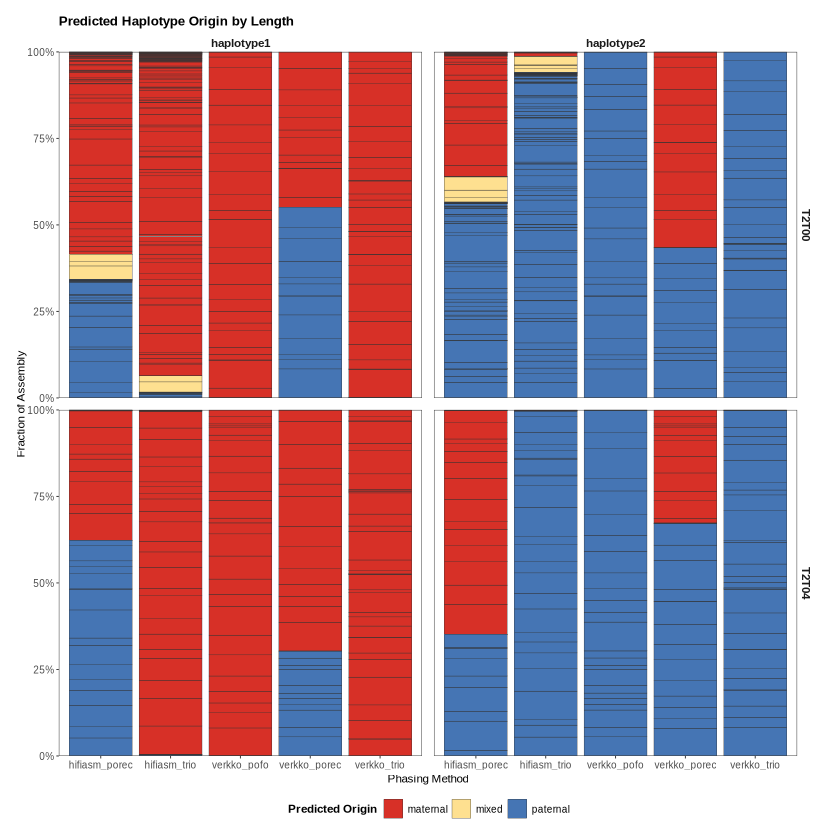

In [31]:
# Plot 4: Predicted origin distribution
dt_origin <- dt_trioeval_contigs %>%
    group_by(sample, method, haplotype, predicted_origin) %>%
    group_by(sample, method, haplotype) %>%
    mutate(
        fraction_by_length = length / sum(length)
    )

p_origin <- ggplot(dt_origin, 
    aes(x = method, y = fraction_by_length, fill = predicted_origin)) +
    geom_col(position = "stack", col = "grey20", lwd = 0.1) +
    facet_grid(sample ~ haplotype) +
    scale_y_continuous(labels = scales::percent, expand = c(0, 0)) +
    scale_fill_manual(
        values = c("paternal" = "#4575b4", "maternal" = "#d73027", "mixed" = "#fee090"),
        name = "Predicted Origin"
    ) +
    labs(
        title = "Predicted Haplotype Origin by Length",
        x = "Phasing Method",
        y = "Fraction of Assembly"
    ) +
    theme(legend.position = "bottom")

p_origin

Interpretation: 
- Trio phasing is correct for most of the samples, some mixed for hifiasm trio
- PoreC labelling of hap1 / hap2 does not correlate stronly with mat / pat. This is expected
- Pofo detection worked perfectly for the two samples with haplotypes available

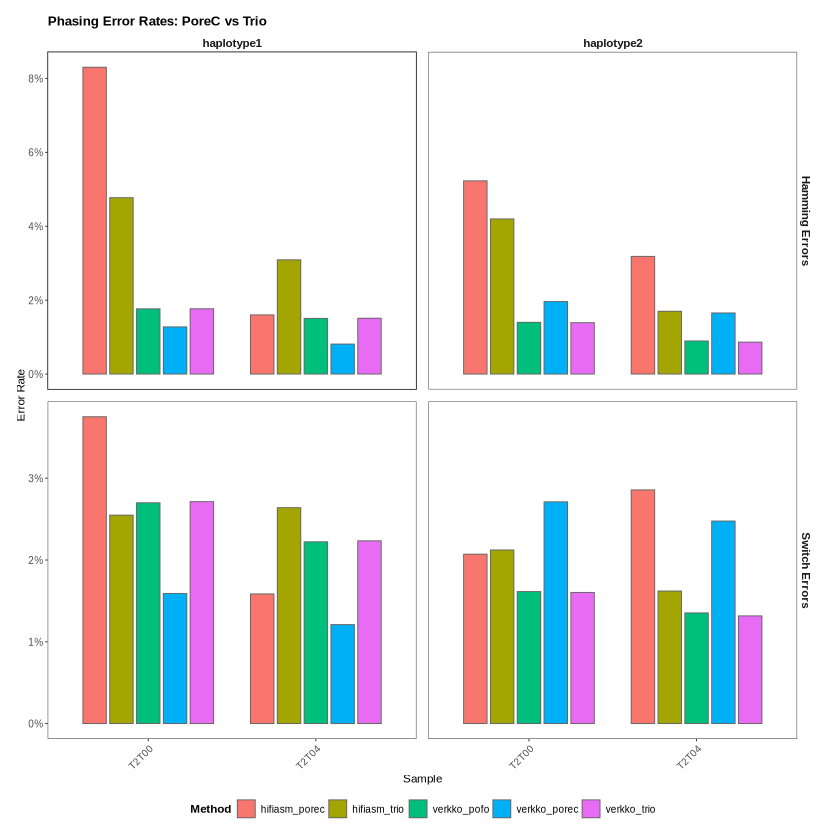

In [33]:
    # Plot 5: Combined error metrics comparison
    dt_errors_long <- dt_trioeval_summary %>%
        select(sample, method, haplotype, switch_error_rate, hamming_error_rate) %>%
        pivot_longer(
            cols = ends_with("_error_rate"),
            names_to = "error_type",
            values_to = "error_rate"
        ) %>%
        mutate(error_type = recode(error_type,
            "switch_error_rate" = "Switch Errors",
            "hamming_error_rate" = "Hamming Errors",
        ))

    p_errors_combined <- ggplot(dt_errors_long, 
        aes(x = sample, y = error_rate, fill = method)) +
        geom_col(position = position_dodge(width = 0.8), col = "grey40", width= 0.7) +
        facet_grid(error_type ~ haplotype, scales = "free_y") +
        scale_y_continuous(labels = scales::percent) +
        labs(
            title = "Phasing Error Rates: PoreC vs Trio",
            x = "Sample",
            y = "Error Rate",
            fill = "Method"
        ) +
        theme(
            axis.text.x = element_text(angle = 45, hjust = 1),
            legend.position = "bottom"
        )

    p_errors_combined

    ggsave("../../doc/figures/trioeval_errors_combined.png", 
           p_errors_combined, width = 8, height = 6, dpi = 300)

Total error rate = proportion of k-mers asigned to the wrong parent. In this case mismatch between haplotype and parent.

In [34]:
dt_switches <- read_tsv("../../analysis_other/trioeval/trioeval_switches.tsv", show_col_types = F)
dt_phaseblocks <- read_tsv("../../analysis_other/trioeval/trioeval_phaseblocks.tsv", show_col_types = F)

# Prepare per-contig error data from switches
dt_contig_switch_errors <- dt_switches %>%
    group_by(sample, method, haplotype, contig) %>%
    summarise(
        n_switches = n(),
        mean_kmer_support = mean((from_kmer_count + to_kmer_count) / 2),
        .groups = "drop"
    ) %>%
    mutate(error_type = "Switch Errors")

# Get contig lengths from trioeval_contigs
dt_contig_info <- dt_trioeval_contigs %>%
    select(sample, method, haplotype, contig, length) %>%
    distinct()

# Join errors with contig info
dt_contig_errors_switches <- dt_contig_switch_errors %>%
    left_join(dt_contig_info, by = c("sample", "method", "haplotype", "contig")) %>%
    rename(n_errors = n_switches)

# Prepare hamming errors per contig from phase blocks
dt_contig_hamming_errors <- dt_phaseblocks %>%
    group_by(sample, method, haplotype, contig) %>%
    summarise(
        n_transitions = sum(c(0, diff(as.numeric(factor(block_type)))) != 0),
        total_kmers = sum(kmer_count),
        .groups = "drop"
    ) %>%
    left_join(dt_contig_info, by = c("sample", "method", "haplotype", "contig")) %>%
    mutate(error_type = "Hamming Errors") %>%
    rename(n_errors = n_transitions)

# Combine both error types
dt_contig_errors <- bind_rows(
    dt_contig_errors_switches %>% select(sample, method, haplotype, contig, length, n_errors, error_type),
    dt_contig_hamming_errors %>% select(sample, method, haplotype, contig, length, n_errors, error_type)
)


### Phase block analysis

In [22]:
# Needs special version of ggideogram with fixes for current ggplot
remotes::install_github("caspargross/ggideogram")
library(ggideogram)
packageDescription("ggideogram")[c("RemoteUsername", "RemoteSha", "Built")]

Skipping install of 'ggideogram' from a github remote, the SHA1 (427202e6) has not changed since last install.
  Use `force = TRUE` to force installation



$RemoteUsername
[1] "caspargross"

$RemoteSha
[1] "427202e60c52d176ef088de6262cebd08449014f"

$Built
[1] "R 4.5.2; ; 2026-06-25 11:44:25 UTC; unix"

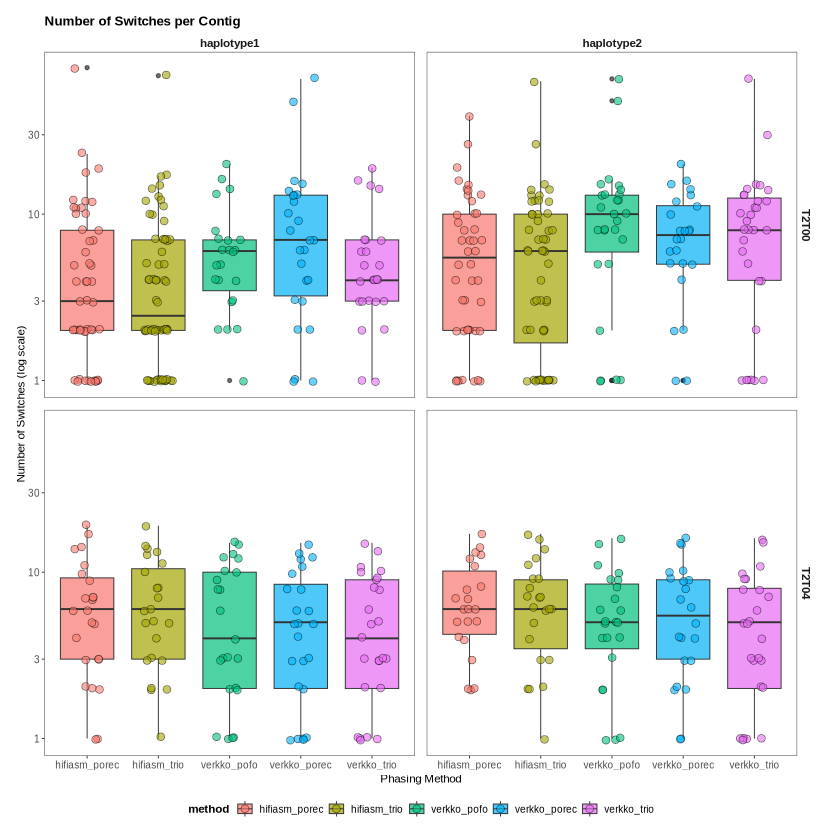

In [23]:
# Plot 1: Number of switches per contig
p_switches_count <- dt_switches %>%
    count(sample, method, haplotype, contig) %>%
    ggplot(aes(x = method, y = n, fill = method)) +
    geom_boxplot(alpha = 0.7) +
    geom_jitter(width = 0.2, shape = 21, size = 2, alpha = 0.6) +
    facet_grid(sample ~ haplotype) +
    scale_y_log10() +
    labs(
        title = "Number of Switches per Contig",
        x = "Phasing Method",
        y = "Number of Switches (log scale)"
    ) +
    theme(legend.position = "bottom")

p_switches_count

# Plot 2: K-mer support at switches
dt_switches_long <- dt_switches %>%
    pivot_longer(
        cols = c(from_kmer_count, to_kmer_count),
        names_to = "position",
        values_to = "kmer_count"
    ) %>%
    mutate(position = recode(position,
        "from_kmer_count" = "Before Switch",
        "to_kmer_count" = "After Switch"
    ))

ggsave("../../doc/figures/trioeval_switches.png", 
       p_switches_count, width = 6, height = 4, dpi = 300)


In [24]:
dt_phaseblocks

sample,method,haplotype,contig,block_type,start,end,length,kmer_count,chr,ref_start,ref_end,strand,mapq
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
T2T00,verkko_porec,haplotype1,haplotype1-0000003,paternal,3589,39895,36306,36,chr21,45045568,45081855,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,maternal,116349,202973,86624,6,chr21,44882574,44969153,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,paternal,263176,323043,59867,49,chr21,44762566,44822402,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,maternal,323374,323419,45,1,chr21,44762190,44762235,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,paternal,323871,368920,45049,57,chr21,44716713,44761738,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,maternal,370968,371008,40,1,chr21,44714626,44714666,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,paternal,370986,416978,45992,62,chr21,44668680,44714648,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,maternal,418319,418354,35,1,chr21,44667304,44667339,-,60
T2T00,verkko_porec,haplotype1,haplotype1-0000003,paternal,420543,676959,256416,281,chr21,44408833,44665116,-,60


In [25]:
# Filter to mapped regions only and prepare for ideogram plotting
dt_phaseblocks_chr <- dt_phaseblocks %>%
    filter(chr != "unmapped", !is.na(ref_start), !is.na(ref_end)) %>%
    mutate(
        chr_num = case_when(
            chr == "chrX" ~ 23,
            chr == "chrY" ~ 24,
            TRUE ~ as.numeric(str_remove(chr, "chr"))
        ),
        chr = factor(chr, levels = unique(chr[order(chr_num)]))
    )

# Check data
dt_phaseblocks_chr %>%
    group_by(sample, method, haplotype, chr) %>%
    summarise(
        n_blocks = n(),
        total_length = sum(ref_end - ref_start),
        .groups = "drop"
    ) %>%
    print(n = 20)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


# A tibble: 462 × 6
   sample method        haplotype  chr   n_blocks total_length
   <chr>  <chr>         <chr>      <fct>    <int>        <dbl>
 1 T2T00  hifiasm_porec haplotype1 chr1      6136    202876143
 2 T2T00  hifiasm_porec haplotype1 chr2      4928    198135393
 3 T2T00  hifiasm_porec haplotype1 chr3      4515    169503446
 4 T2T00  hifiasm_porec haplotype1 chr4      3449    161667908
 5 T2T00  hifiasm_porec haplotype1 chr5      3766    148945639
 6 T2T00  hifiasm_porec haplotype1 chr6      3869    138520142
 7 T2T00  hifiasm_porec haplotype1 chr7      3789    127654993
 8 T2T00  hifiasm_porec haplotype1 chr8      3332    116170659
 9 T2T00  hifiasm_porec haplotype1 chr9      2946    114128304
10 T2T00  hifiasm_porec haplotype1 chr10     3261    110323530
11 T2T00  hifiasm_porec haplotype1 chr11     3004    112285534
12 T2T00  hifiasm_porec haplotype1 chr12     3285    107139935
13 T2T00  hifiasm_porec haplotype1 chr13     2562     90165320
14 T2T00  hifiasm_porec haplotype1 

[1] "Processing sample: T2T00"
[1] "Processing sample: T2T04"


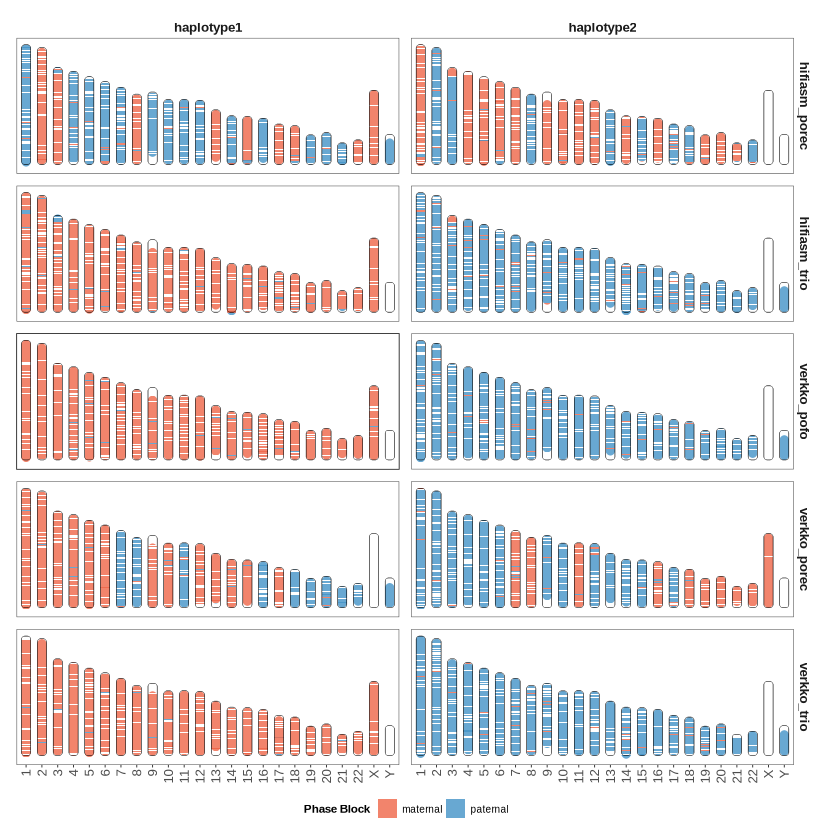

In [26]:
for (sample_name in unique(dt_phaseblocks_chr$sample)) { 
    print(paste("Processing sample:", sample_name))
    # Create karyogram with phase blocks
    p_phaseblock_karyogram <- ggplot() +
        # Phase blocks
        ggideogram::geom_ideogram(
            data = dt_phaseblocks_chr %>% filter(sample == sample_name),
            aes(x = chr, ymin = ref_start, ymax = ref_end, chrom = chr, 
                fill = block_type),
            radius = unit(3, 'pt'), 
            width = 0.6, 
            linewidth = 0,
            alpha = 0.8
        ) +
        # Base ideogram
        ggideogram::geom_ideogram(
            data = karyotype_chm13,
            aes(x = chr, ymin = start, ymax = end, chrom = chr),
            radius = unit(2, 'pt'), 
            width = 0.6, 
            linewidth = 0.2,
            colour = 'black',
            fill = 'transparent'
        ) +
        facet_grid(method ~ haplotype) +
        scale_fill_manual(
            values = col_haplotype,
            name = "Phase Block"
        ) +
        scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
        #labs(title = paste("Phase Blocks for Sample", sample_name)) +
        theme(
            axis.title = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
            panel.grid = element_blank(),
            strip.text = element_text(face = "bold", size = 8),
            legend.position = "bottom"
        )
    
    ggsave(paste0("../../doc/figures/trioeval_phaseblock_karyogram_", sample_name, ".png"), 
        p_phaseblock_karyogram, width = 7, height = 10, dpi = 300)

}

p_phaseblock_karyogram

[1] "Processing sample: T2T00"
[1] "Processing sample: T2T04"


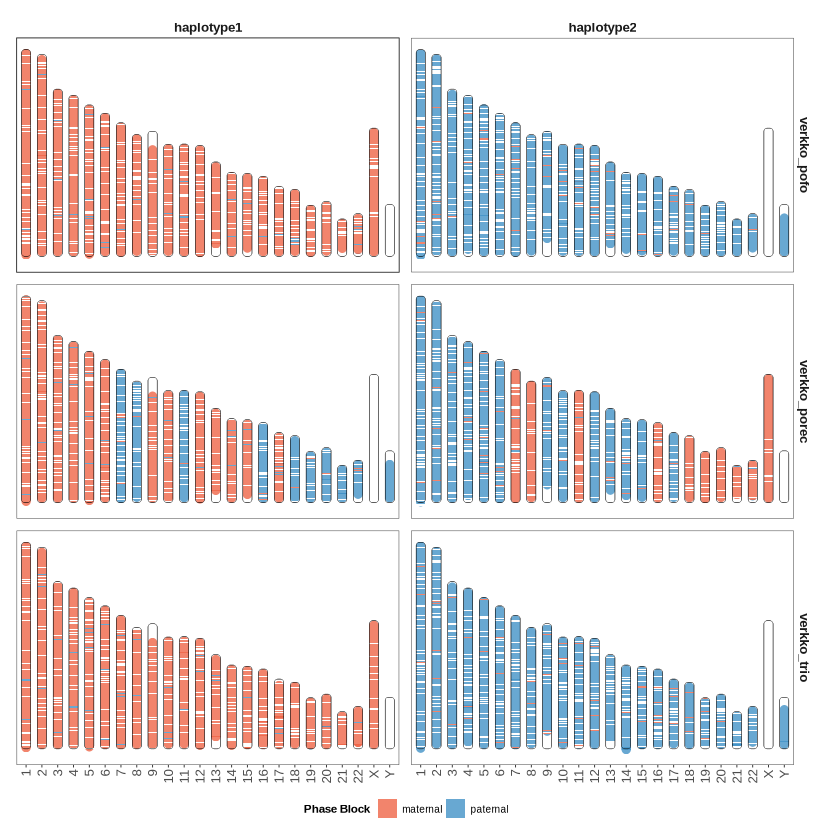

In [35]:
# Karyotypes verkko only 
for (sample_name in unique(dt_phaseblocks_chr$sample)) { 
    print(paste("Processing sample:", sample_name))
    # Create karyogram with phase blocks
    p_phaseblock_karyogram <- ggplot() +
        # Phase blocks
        ggideogram::geom_ideogram(
            data = dt_phaseblocks_chr %>% filter(sample == sample_name) %>% filter(str_detect(method, "verkko")),
            aes(x = chr, ymin = ref_start, ymax = ref_end, chrom = chr, 
                fill = block_type),
            radius = unit(3, 'pt'), 
            width = 0.6, 
            linewidth = 0,
            alpha = 0.8
        ) +
        # Base ideogram
        ggideogram::geom_ideogram(
            data = karyotype_chm13,
            aes(x = chr, ymin = start, ymax = end, chrom = chr),
            radius = unit(2, 'pt'), 
            width = 0.6, 
            linewidth = 0.2,
            colour = 'black',
            fill = 'transparent'
        ) +
        facet_grid(method ~ haplotype) +
        scale_fill_manual(
            values = col_haplotype,
            name = "Phase Block"
        ) +
        scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
        #labs(title = paste("Phase Blocks for Sample", sample_name)) +
        theme(
            axis.title = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank(),
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
            panel.grid = element_blank(),
            strip.text = element_text(face = "bold", size = 8),
            legend.position = "bottom"
        )
    
    ggsave(paste0("../../doc/figures/trioeval_phaseblock_karyogram_verkko_", sample_name, ".png"), 
        p_phaseblock_karyogram, width = 7, height = 10, dpi = 300)

}

p_phaseblock_karyogram

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


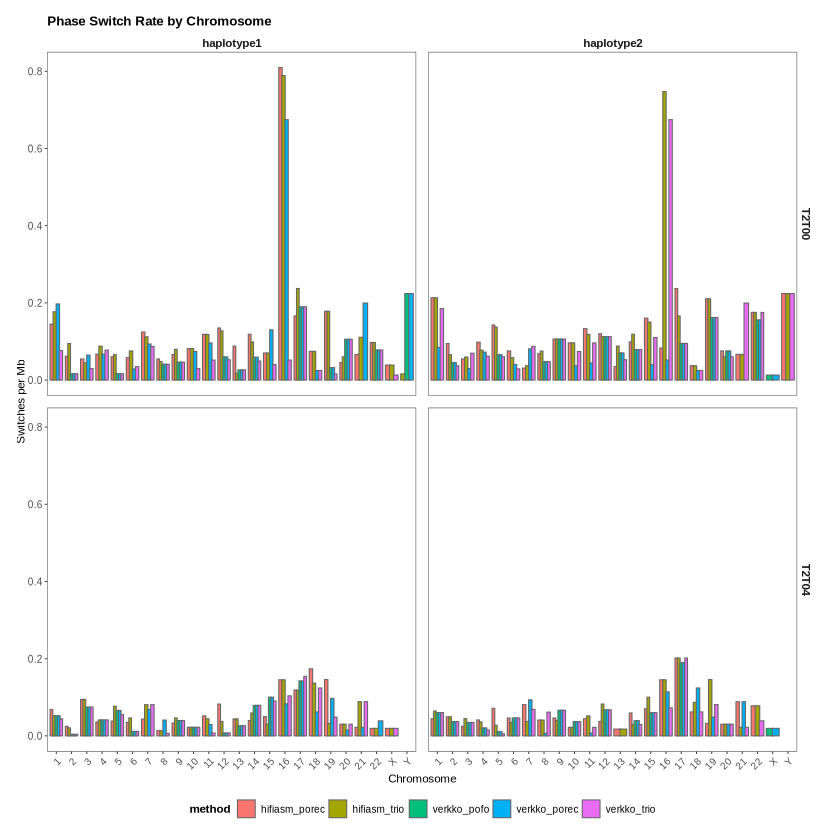

In [14]:
# Updated switch rate per chromosome plot (now using chr column directly)
dt_switches_chr <- dt_switches %>%
    filter(chr != "unmapped", !is.na(chr)) %>%
    mutate(
        chr_num = case_when(
            chr == "chrX" ~ 23,
            chr == "chrY" ~ 24,
            TRUE ~ as.numeric(str_remove(chr, "chr"))
        ),
        chr = factor(chr, levels = unique(chr[order(chr_num)]))
    )

# Calculate switch rate per chromosome
chr_lengths <- karyotype_chm13 %>%
    select(chr, chr_length = end)

dt_switch_rate_chr <- dt_switches_chr %>%
    group_by(sample, method, haplotype, chr) %>%
    summarise(n_switches = n(), .groups = "drop") %>%
    left_join(chr_lengths, by = "chr") %>%
    mutate(switches_per_mb = n_switches / (chr_length / 1e6))

p_switch_rate_chr <- ggplot(dt_switch_rate_chr,
    aes(x = chr, y = switches_per_mb, fill = method)) +
    geom_col(position = position_dodge(width = 0.8), color = "grey40", linewidth = 0.3) +
    facet_grid(sample ~ haplotype) +
    scale_y_continuous(name = "Switches per Mb") +
    scale_x_discrete(name = "Chromosome", labels = function(x) gsub("chr", "", x)) +
    labs(title = "Phase Switch Rate by Chromosome") +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

ggsave("../../doc/figures/trioeval_switch_rate_by_chr.png", 
       p_switch_rate_chr, width = 6, height = 4, dpi = 300)

p_switch_rate_chr